<a href="https://colab.research.google.com/github/AndrsGzRo/prediccion-afluencia-metrocdmx/blob/main/Prediccion_Metro_CDMX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Afluencia del Metro de la Ciudad de México

## 1. Exploración preliminar del dataframe

In [261]:
# Importando librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [262]:
# Dataframe
url = 'https://github.com/AndrsGzRo/prediccion-afluencia-metrocdmx/raw/main/Afluencia_Diaria_MetroCDMX.zip'
df_raw = pd.read_csv(url,compression='zip')
df_raw.head()

,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499


### 1.1 Información sobre el dataframe

In [263]:
def info_df(df):
    print('---------Información general del Dataframe---------')
    print(df.info())
    print('---------Estadísticas del df---------')
    print(df.describe())
    print('---------Valores nulos---------')
    print(df.isnull().sum().sort_values(ascending=False))
    print('---------Valores únicos---------')
    print(df.nunique())

info_df(df_raw)

---------Información general del Dataframe---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1121640 entries, 0 to 1121639
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   fecha      1121640 non-null  object
 1   anio       1121640 non-null  int64 
 2   mes        1121640 non-null  object
 3   linea      1121640 non-null  object
 4   estacion   1121640 non-null  object
 5   afluencia  1121640 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 51.3+ MB
None
---------Estadísticas del df---------
               anio     afluencia
count  1.121640e+06  1.121640e+06
mean   2.017380e+03  1.969899e+04
std    4.547000e+00  1.947216e+04
min    2.010000e+03  0.000000e+00
25%    2.013000e+03  7.435000e+03
50%    2.017000e+03  1.445200e+04
75%    2.021000e+03  2.551000e+04
max    2.025000e+03  2.630560e+05
---------Valores nulos---------
fecha        0
anio         0
mes          0
linea        0
estacion     0
a

### 1.2 Convertir fecha a ```datetime```

In [264]:
df = df_raw.copy()
df['fecha'] = pd.to_datetime(df['fecha'],errors='coerce')
df['fecha'].dtype

dtype('<M8[ns]')

### 1.3 Convertir mes a número

In [265]:
meses = {
    'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,'Julio':7,
    'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12}

df['mes_num'] = df['mes'].map(meses)

df[['mes','mes_num']].head()

,mes,mes_num
0,Enero,1
1,Enero,1
2,Enero,1
3,Enero,1
4,Enero,1


### 1.4 Obtener día de la fecha

In [266]:
df['día'] = df['fecha'].dt.day
df['día_semana'] = df['fecha'].dt.day_name()
df['día_semana'] = df['día_semana'].replace({
    'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado',
    'Sunday':'Domingo'
})
df['día_semana'].unique()
df.head()

,fecha,anio,mes,linea,estacion,afluencia,mes_num,día,día_semana
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227,1,1,Viernes
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487,1,1,Viernes
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304,1,1,Viernes
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679,1,1,Viernes
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499,1,1,Viernes


### 1.5 Correción de nombre de las estaciones

In [267]:
df['estacion'] = df['estacion'].replace({
    'Isabel la CatÃ³lica':'Isabel la Católica', 'Pino SuÃ¡rez':'Pino Suárez',
    'GÃ³mez FarÃ\xadas':'Gómez Farías','La Villa/BasÃ\xadlica':'La Villa-Basílica',
    'PantitlÃ¡n':'Pantitlán','VelÃ³dromo':'Velódromo','RefinerÃ\xada':'Refinería',
    'EtiopÃ\xada/Plaza de la Transparencia':'Etiopía/ Plaza de la Transparencia',
    'DivisiÃ³n del Norte':'División del Norte',
    'FerrerÃ\xada/Arena Ciudad de MÃ©xico':'Ferretería/Arena Ciudad de México',
    'Instituto del PetrÃ³leo':'Instituto del Petróleo','San Juan de LetrÃ¡n':'San Juan Letrán',
    'OceanÃ\xada':'Ocenía','NezahualcÃ³yotl':'Nezahualcóyotl','RevoluciÃ³n':'Revolución',
    'JuÃ¡rez':'Juárez','OlÃ\xadmpica':'Olímpica','CulhuacÃ¡n':'Culhuacán',
    'PeÃ±Ã³n Viejo':'Peñón Viejo','San AndrÃ©s TomatlÃ¡n':'San Andrés Tomatlán',
    'AragÃ³n':'Aragón','MartÃ\xadn Carrera':'Martín Carrera','Aquiles SerdÃ¡n':'Aquiles Serdán',
    'San JoaquÃ\xadn':'San Joaquín','TezozÃ³moc':'Tezozómoc','CuitlÃ¡huac':'Cuitláhuac',
    'Terminal AÃ©rea':'Terminal Aérea','Centro MÃ©dico':'Centro Médico','CoyoacÃ¡n':'Coyoacán',
    'ZÃ³calo/Tenochtitlan':'Zócalo/Tenochtitlan','Boulevard Puerto AÃ©reo':'Boulevard Puerto Aéreo',
    'Villa de CortÃ©s':'Villa de Cortés','TalismÃ¡n':'Talismán','Valle GÃ³mez':'Valle Gómez',
    'PolitÃ©cnico':'Politécnico','NiÃ±os HÃ©roes':'Niños Héroes','TasqueÃ±a':'Tasqueña',
    'JuanacatlÃ¡n':'Juanacatlán','Plaza AragÃ³n':'Plaza Aragón','ZapotitlÃ¡n':'Zapotitlán',
    'RÃ\xado de los Remedios':'Río de los Remedios','MÃºzquiz':'Múzquiz',
    'EscuadrÃ³n 201':'Escuadrón 201','PerifÃ©rico Oriente':'Periférico Oriente',
    'TlÃ¡huac':'Tláhuac','San LÃ¡zaro':'San Lázaro','Villa de AragÃ³n':'Villa de Aragón',
    'AgrÃ\xadcola Oriental':'Agrícola Oriental','Deportivo OceanÃ\xada':'Deportivo Oceanía',
    'Bosque de AragÃ³n':'Bosque de Aragón','ConstituciÃ³n de 1917':'Constitución de 1917',
    'CuauhtÃ©moc':'Cuauhtémoc','Ricardo Flores MagÃ³n':'Ricardo Flores Magón',
    'LÃ¡zaro CÃ¡rdenas':'Lázaro Cárdenas','GÃ³mez Farias':'Gómez Farías',
    'PeÃ±Ã³n viejo':'Peñón Viejo','Miguel Ã\x81ngel de Quevedo':'Miguel Ángel de Quevedo'
})

### 1.6 Correción de Líneas

In [268]:
df['linea'].unique()

array(['Linea 1', 'Linea 6', 'Linea 9', 'Linea 8', 'Linea 5', 'Linea 7',
       'Linea 3', 'Linea 4', 'Linea 2', 'Linea B', 'Linea 12', 'Linea A',
       'LÃ\xadnea 1', 'LÃ\xadnea 12', 'LÃ\xadnea 2', 'LÃ\xadnea 3',
       'LÃ\xadnea 4', 'LÃ\xadnea 5', 'LÃ\xadnea 6', 'LÃ\xadnea 7',
       'LÃ\xadnea 8', 'LÃ\xadnea 9', 'LÃ\xadnea A', 'LÃ\xadnea B'],
      dtype=object)

In [269]:
# Reemplazar valores mal codificados de las líneas del Metro CDMX
df['linea'] = df['linea'].replace({
    'LÃ\xadnea 1': 'Línea 1','LÃ\xadnea 2': 'Línea 2','LÃ\xadnea 3': 'Línea 3',
    'LÃ\xadnea 4': 'Línea 4','LÃ\xadnea 5': 'Línea 5','LÃ\xadnea 6': 'Línea 6',
    'LÃ\xadnea 7': 'Línea 7','LÃ\xadnea 8': 'Línea 8','LÃ\xadnea 9': 'Línea 9',
    'LÃ\xadnea 12': 'Línea 12','LÃ\xadnea A': 'Línea A','LÃ\xadnea B': 'Línea B',
    'Linea 1':'Línea 1', 'Linea 6':'Línea 6','Linea 9':'Línea 9','Linea 8':'Línea 8',
    'Linea 5':'Línea 5','Linea 7':'Línea 7','Linea 3':'Línea 3','Linea 4':'Línea 4',
    'Linea 2':'Línea 2','Linea B':'Línea B','Linea 12':'Línea 12','Linea A':'Línea A'
})


### 1.7 Información Dataframe limpio

In [270]:
info_df(df)

---------Información general del Dataframe---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1121640 entries, 0 to 1121639
Data columns (total 9 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   fecha       1121640 non-null  datetime64[ns]
 1   anio        1121640 non-null  int64         
 2   mes         1121640 non-null  object        
 3   linea       1121640 non-null  object        
 4   estacion    1121640 non-null  object        
 5   afluencia   1121640 non-null  int64         
 6   mes_num     1121640 non-null  int64         
 7   día         1121640 non-null  int32         
 8   día_semana  1121640 non-null  object        
dtypes: datetime64[ns](1), int32(1), int64(3), object(4)
memory usage: 72.7+ MB
None
---------Estadísticas del df---------
                               fecha          anio     afluencia  \
count                        1121640  1.121640e+06  1.121640e+06   
mean   2017-11-15 11:59:59.

## 2. Visualizaciones para entender el Dataframe

In [271]:
sns.set_theme(style='darkgrid')
metro_color = '#FE5000'
colores_metro = {
    'Línea 1':'#F04E98',
    'Línea 2':'#005EB8',
    'Línea 3':'#AF9800',
    'Línea 4':'#6BBBAE',
    'Línea 5':'#FFD100',
    'Línea 6':'#DA291C',
    'Línea 7':'#E87722',
    'Línea 8':'#009444',
    'Línea 9':'#512F2E',
    'Línea A':'#981D97',
    'Línea B':'#B1B3B3',
    'Línea 12':'#B0A32A'
}


###  Evolución de Afluencia

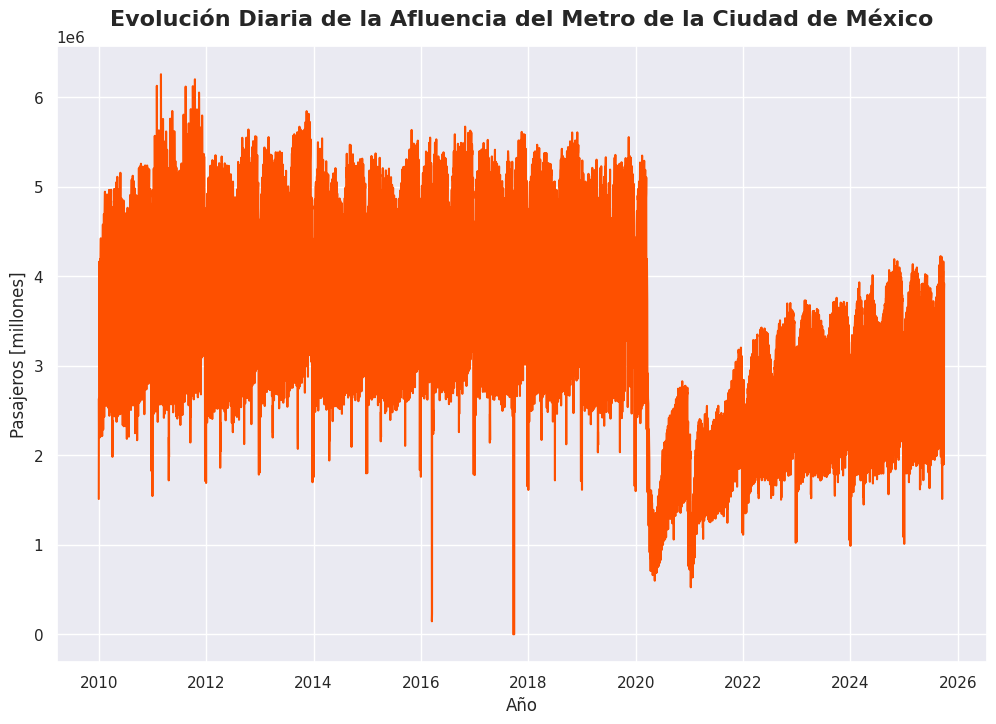

In [272]:
afluencia_fecha = (
    df.groupby('fecha')['afluencia'].sum().reset_index(name='Afluencia')
)

# Visualización
plt.figure(figsize=(12,8))
sns.lineplot(
    data=afluencia_fecha,x='fecha',
    y='Afluencia',color=metro_color)
plt.xlabel('Año',fontsize=12)
plt.ylabel('Pasajeros [millones]',fontsize=12)
plt.title('Evolución Diaria de la Afluencia del Metro de la Ciudad de México',
          fontsize=16,fontweight='bold',pad=15)
plt.show()

###  Afluencia promedio por línea

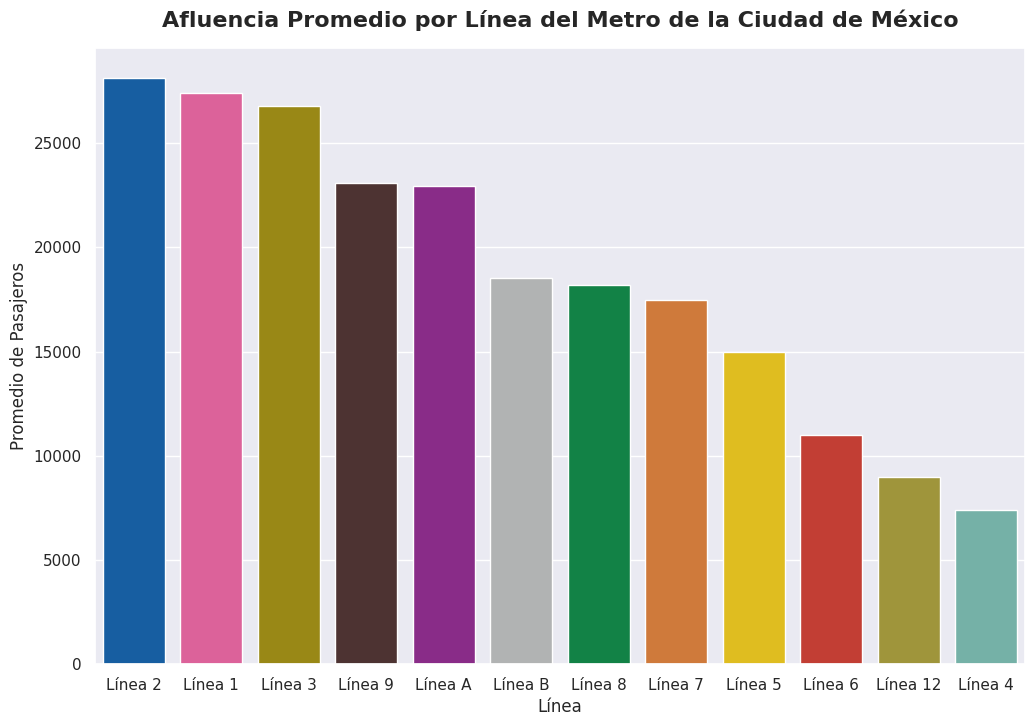

In [273]:
afluenciaprom_linea = (
    df.groupby('linea')['afluencia'].mean().sort_values(ascending=False).reset_index(name='Afluencia')
)
# Visualización
plt.figure(figsize=(12,8))
sns.barplot(
    data=afluenciaprom_linea,
    x='linea',
    y='Afluencia',
    hue='linea',
    palette=colores_metro)
plt.xlabel('Línea')
plt.ylabel('Promedio de Pasajeros')
plt.title('Afluencia Promedio por Línea del Metro de la Ciudad de México',
          fontsize=16,fontweight='bold',pad=15)
plt.show()

### Evolución de la Afluencia por Línea

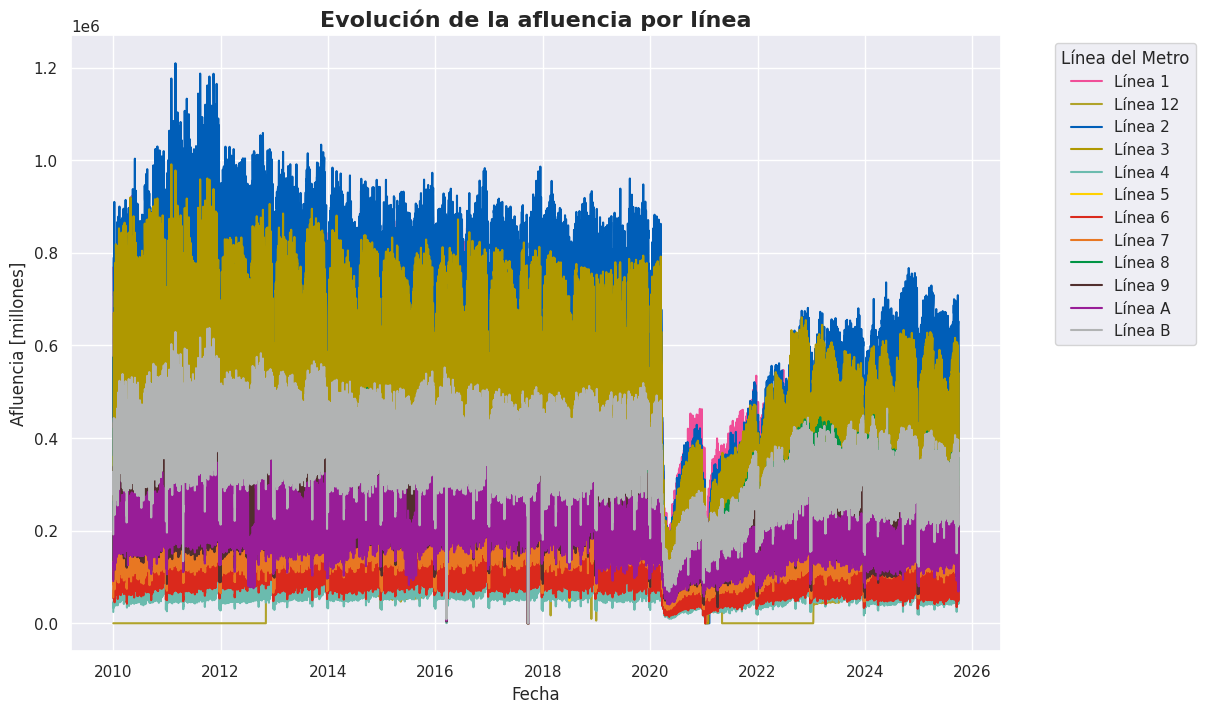

In [274]:
df_lineas = (
    df.groupby(['fecha','linea'])['afluencia'].sum().reset_index()
)
plt.figure(figsize=(12,8))
sns.lineplot(
    data=df_lineas,
    x='fecha',
    y='afluencia',
    hue='linea',
    palette=colores_metro
)
plt.title("Evolución de la afluencia por línea",fontsize=16,fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Afluencia [millones]")
plt.legend(title="Línea del Metro", bbox_to_anchor=(1.05, 1))
plt.show()

### Boxplot por línea

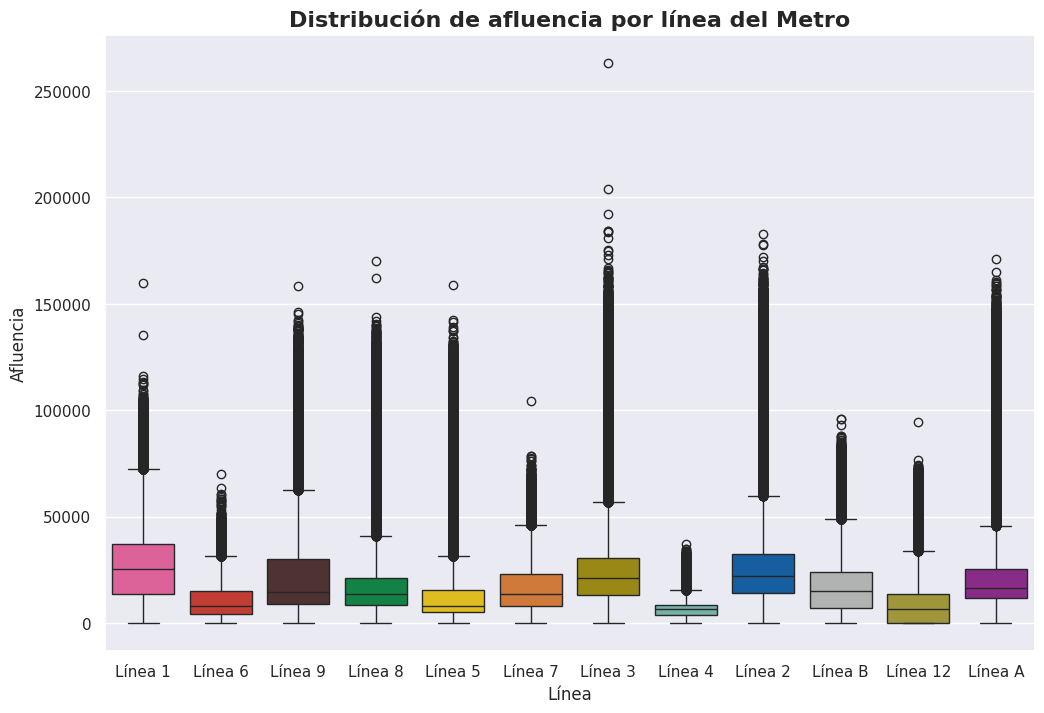

In [275]:
plt.figure(figsize=(12,8))
sns.boxplot(
    data=df,
    x='linea',
    y='afluencia',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('Línea')
plt.ylabel('Afluencia')
plt.title('Distribución de afluencia por línea del Metro',fontsize=16,fontweight='bold')
plt.show()

###  Afluencia mes

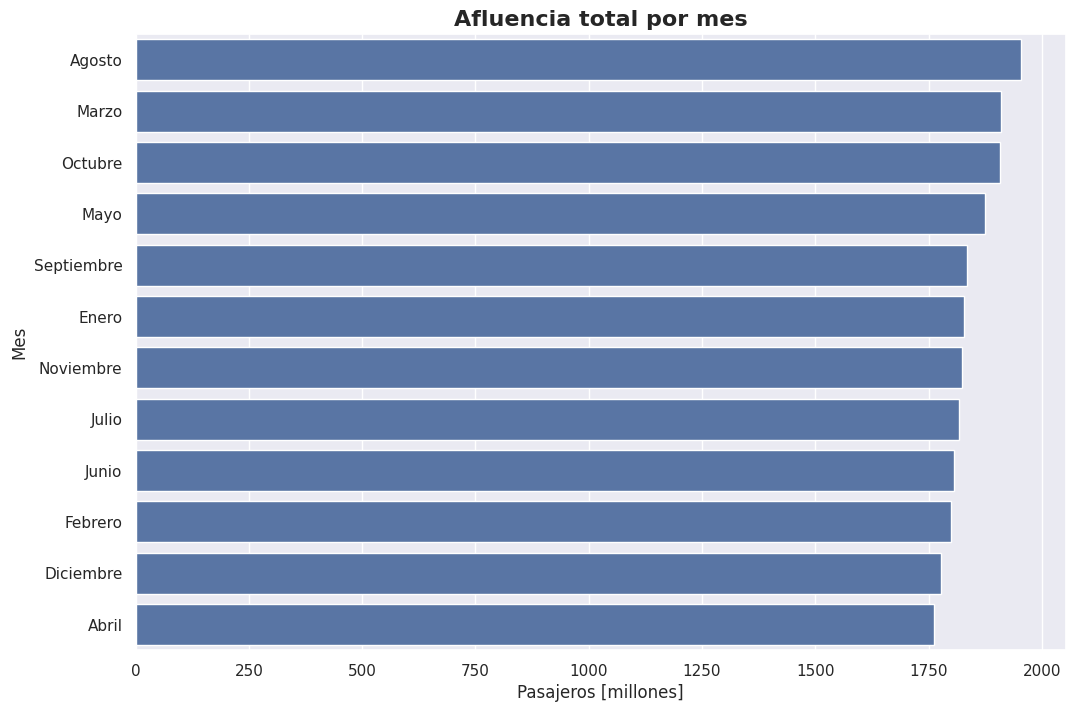

In [276]:
total_mes = (
    df.groupby('mes')['afluencia'].sum().
    sort_values(ascending=False).reset_index(name='Afluencia')
)
total_mes['Afluencia_millones'] = total_mes['Afluencia']/1e6
# Visualización
plt.figure(figsize=(12,8))
sns.barplot(
    data=total_mes,
    y='mes',
    x='Afluencia_millones'
)
plt.xlabel('Pasajeros [millones]')
plt.ylabel('Mes')
plt.title('Afluencia total por mes',fontsize=16,fontweight='bold')
plt.show()

###  Afluencia promedio por mes

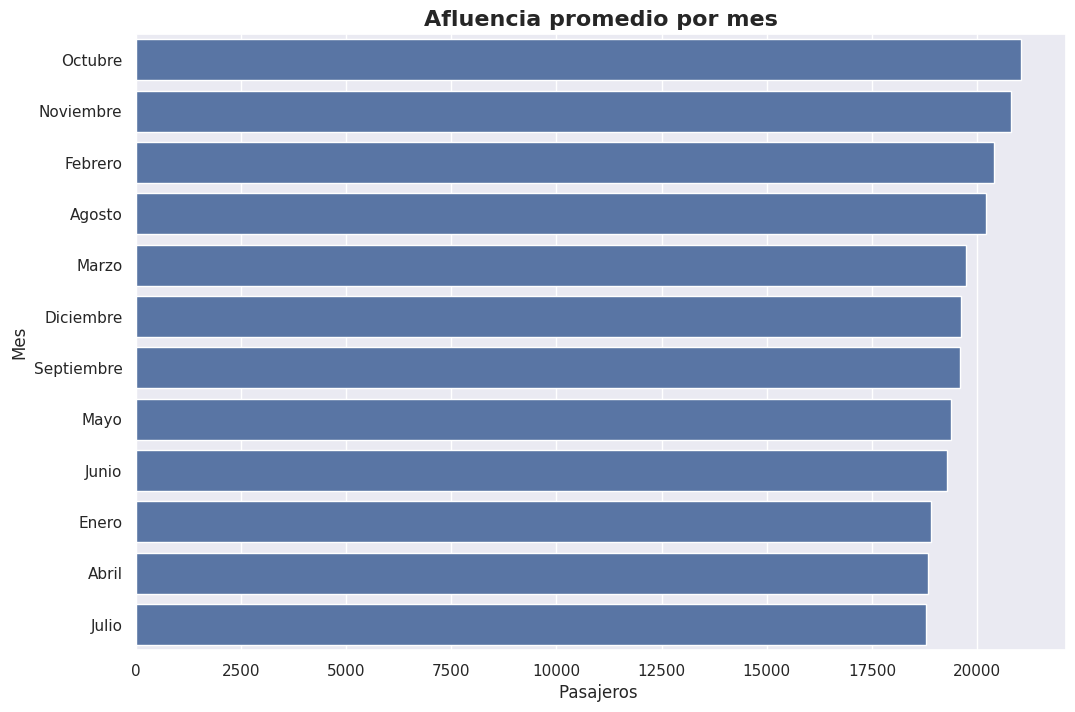

In [277]:
promedio_mes = (
    df.groupby('mes')['afluencia'].mean().
    sort_values(ascending=False).reset_index(name='Afluencia')
)
# Visualización
plt.figure(figsize=(12,8))
sns.barplot(
    data=promedio_mes,
    y='mes',
    x='Afluencia'
)
plt.xlabel('Pasajeros ',fontsize=12)
plt.ylabel('Mes',fontsize=12)
plt.title('Afluencia promedio por mes',fontsize=16,fontweight='bold')
plt.show()

###  Mapa de Calor (Línea vs Mes)

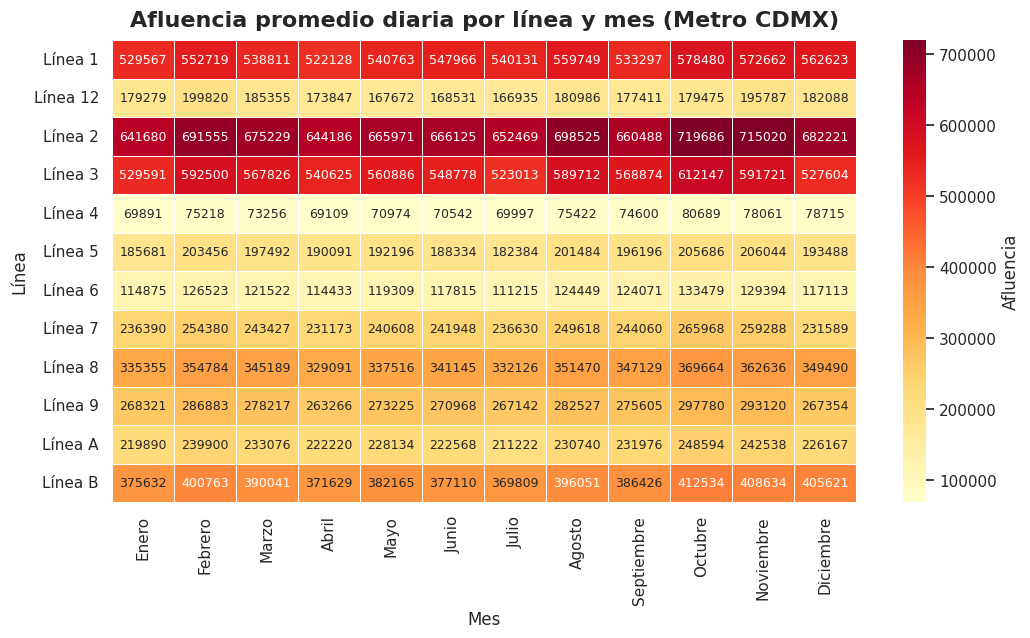

In [278]:
tabla = (
    df.groupby(['linea','mes','fecha'])['afluencia'].sum()
    .groupby(['linea','mes']).mean().unstack()
)
# Ordenar meses
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
               'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
tabla = tabla[orden_meses]

plt.figure(figsize=(12,6))
sns.heatmap(
    tabla,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    annot_kws={'size':9},
    cbar_kws={'label':'Afluencia'}
)
plt.title('Afluencia promedio diaria por línea y mes (Metro CDMX)',fontsize=16,
          fontweight='bold',pad=10)
plt.xlabel('Mes')
plt.ylabel('Línea')
plt.show()

### Top 10 estaciones con mayor afluencia

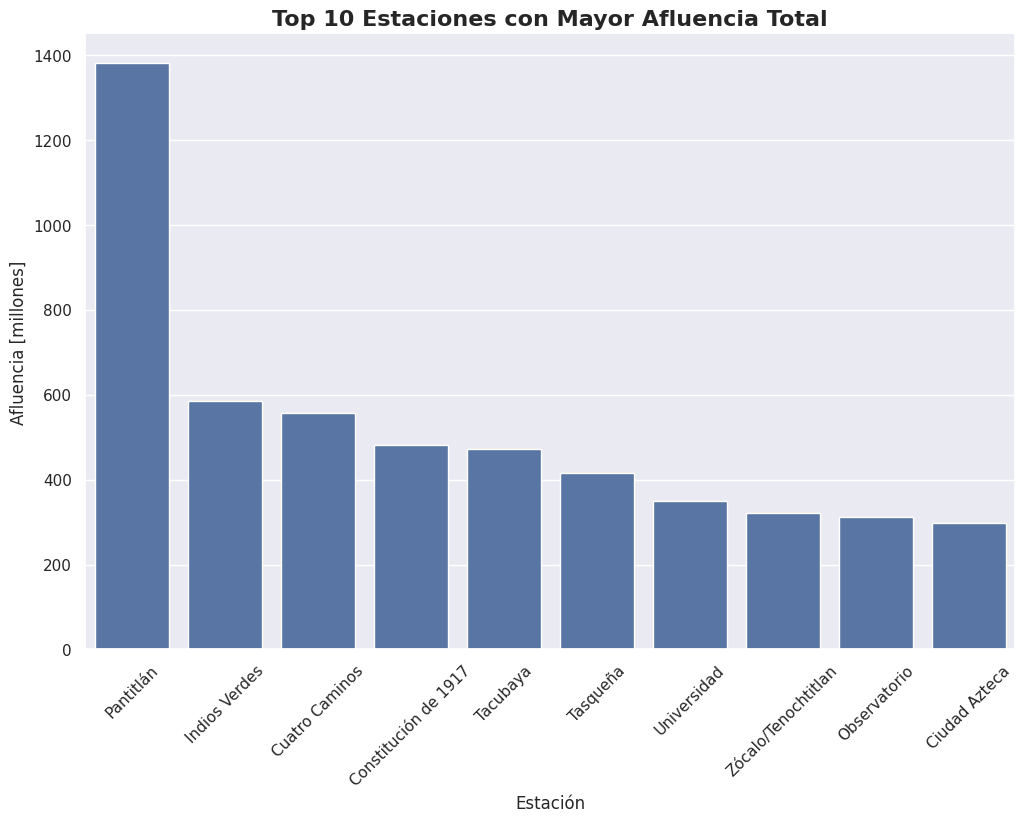

In [279]:
top10 = (
    df.groupby('estacion')['afluencia'].sum().
    sort_values(ascending=False).head(10).reset_index()
)
top10['afluencia_millones'] = top10['afluencia']/1e6
plt.figure(figsize=(12,8))
sns.barplot(
    data=top10,
    x='estacion',
    y='afluencia_millones'
)
plt.xlabel('Estación')
plt.xticks(rotation=45)
plt.ylabel('Afluencia [millones]')
plt.title('Top 10 Estaciones con Mayor Afluencia Total',fontsize=16,fontweight='bold')
plt.show()

### Estaciones menos utilizadas

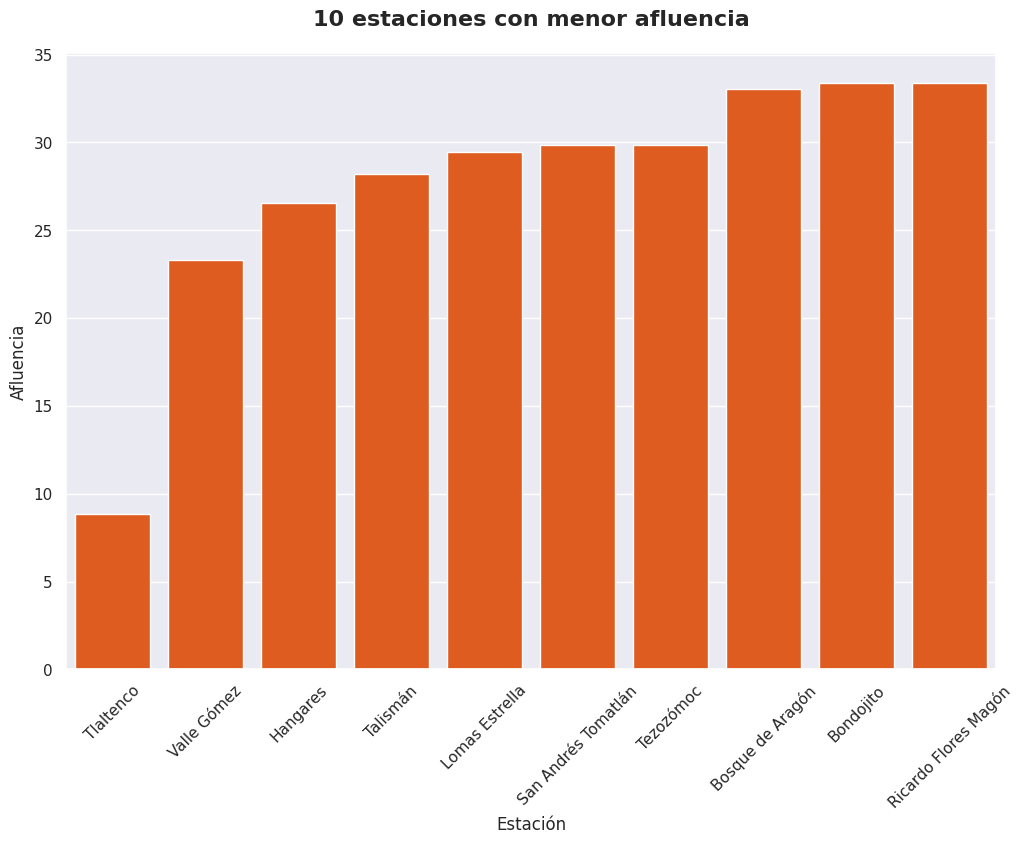

In [280]:
nottop10 = (
    df.groupby('estacion')['afluencia'].sum().sort_values(ascending=True).head(10).
    reset_index()
)
nottop10['afluencia_mill'] = nottop10['afluencia']/1e6
plt.figure(figsize=(12,8))
sns.barplot(
    data=nottop10,
    x='estacion',
    y='afluencia_mill',
    color=metro_color
)
plt.xticks(rotation=45)
plt.xlabel('Estación')
plt.ylabel('Afluencia')
plt.title('10 estaciones con menor afluencia',fontsize=16,fontweight='bold',pad=20)
plt.show()

###Afluencia promedio por día de a semana

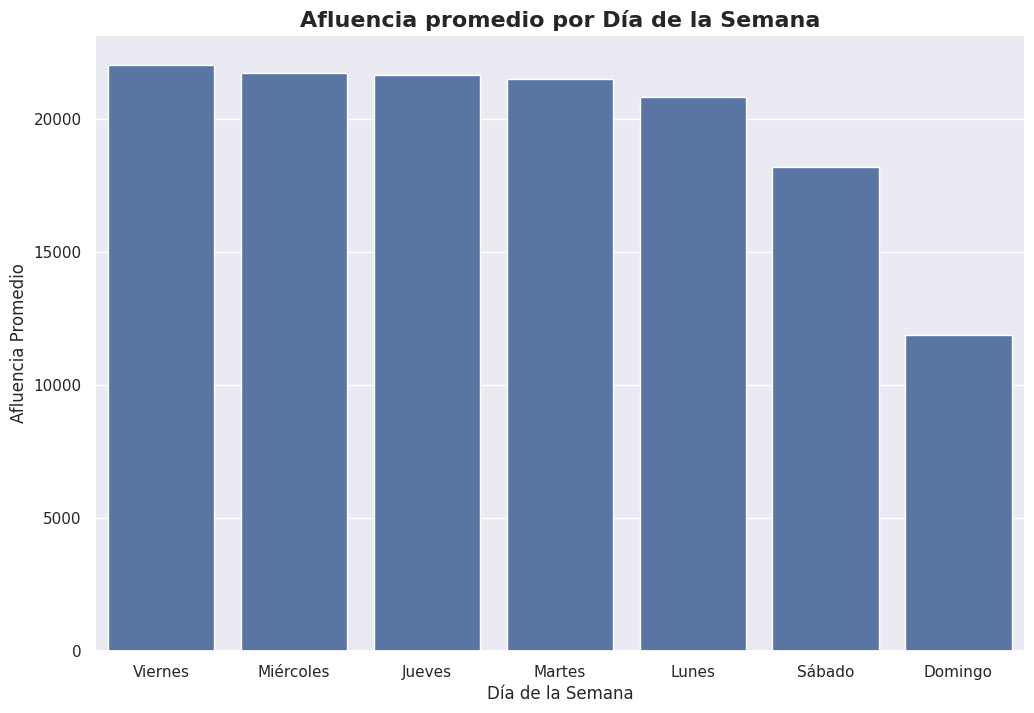

In [281]:
diasemana_prom = (
    df.groupby('día_semana')['afluencia'].mean().
    sort_values(ascending=False).reset_index()
)
plt.figure(figsize=(12,8))
sns.barplot(
    data=diasemana_prom,
    x='día_semana',
    y='afluencia'
)
plt.xlabel('Día de la Semana')
plt.ylabel('Afluencia Promedio')
plt.title('Afluencia promedio por Día de la Semana',fontsize=16,fontweight='bold')
plt.show()

## 3. Sets de entrenamiento, validación y prueba

In [282]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from xgboost import XGBRegressor

### Trabajos previos

In [283]:
# Afluencia diaria por linea
df_lineas = (
    df.groupby(['fecha','linea'])['afluencia'].sum().reset_index()
)
df_lineas.head(10)

,fecha,linea,afluencia
0,2010-01-01,Línea 1,251474
1,2010-01-01,Línea 12,0
2,2010-01-01,Línea 2,285403
3,2010-01-01,Línea 3,228261
4,2010-01-01,Línea 4,24340
5,2010-01-01,Línea 5,98231
6,2010-01-01,Línea 6,54254
7,2010-01-01,Línea 7,56191
8,2010-01-01,Línea 8,136099
9,2010-01-01,Línea 9,94283


#### Feature Engineering

In [284]:
df_lineas['anio'] = df_lineas['fecha'].dt.year
df_lineas['mes'] = df_lineas['fecha'].dt.month
df_lineas['dia'] = df_lineas['fecha'].dt.day
df_lineas['dia_semana'] = df_lineas['fecha'].dt.day_of_week
df_lineas['dia_anio'] = df_lineas['fecha'].dt.dayofyear
df_lineas['es_fin_de_semana'] = (df_lineas['dia_semana'] >= 5).astype(int)
df_lineas.head()


,fecha,linea,afluencia,anio,mes,dia,dia_semana,dia_anio,es_fin_de_semana
0,2010-01-01,Línea 1,251474,2010,1,1,4,1,0
1,2010-01-01,Línea 12,0,2010,1,1,4,1,0
2,2010-01-01,Línea 2,285403,2010,1,1,4,1,0
3,2010-01-01,Línea 3,228261,2010,1,1,4,1,0
4,2010-01-01,Línea 4,24340,2010,1,1,4,1,0


### División de conjuntos de entrenamiento y prueba

In [285]:
train = df_lineas[df_lineas['anio'].between(2010,2024)]
test = df_lineas[df_lineas['anio'] == 2025]

In [286]:
#Dummies de linea
train = pd.get_dummies(train, columns = ['linea'],drop_first=False,dtype=int)
test = pd.get_dummies(test, columns=['linea'],drop_first=False,dtype=int)

train,test = train.align(test,join='left',axis=1,fill_value=0)

### Variables predictores y objetivo

In [287]:
features = ['anio','mes','dia','dia_semana','dia_anio','es_fin_de_semana']
features += [col for col in train.columns if col.startswith('linea_')]

# Entrenamiento
X_train = train[features]
y_train = train['afluencia']

# Prueba
X_test = test[features]
y_test = test['afluencia']

print('X_train tamaño', X_train.shape)
print('y_train tamaño', y_train.shape)
print('X_test tamaño', X_test.shape)
print('y_test tamaño', y_test.shape)

X_train tamaño (65748, 18)
y_train tamaño (65748,)
X_test tamaño (3276, 18)
y_test tamaño (3276,)


### Modelo

In [288]:
model1 = XGBRegressor(
    n_estimators = 200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    random_state=42
)
# Entrenar
model1.fit(X_train,y_train)

# Predicción para 2025
y_pred = model1.predict(X_test)
test['prediccion'] = y_pred

# Evaluacion
mae = mean_absolute_error(y_test,y_pred)
rmse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Prueba (2025)  MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

Prueba (2025)  MAE: 34612.39 | RMSE: 2901454080.00 | R²: 0.885


## 4. Visualizaciones

### Real vs Predicción

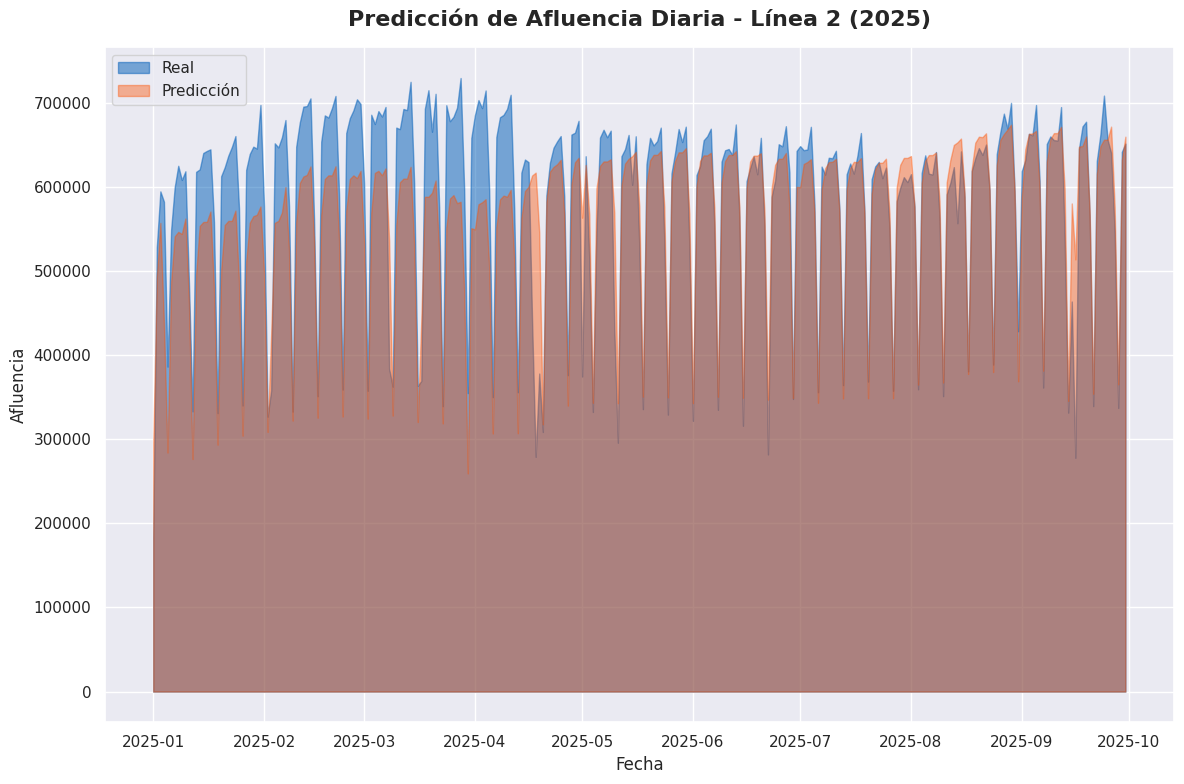

In [289]:
linea2 = test[test['linea_Línea 2'] == 1]

plt.figure(figsize=(12,8))

plt.fill_between(linea2['fecha'], linea2['afluencia'],
                 color='#005EB8', alpha=0.5, label='Real')

plt.fill_between(linea2['fecha'], linea2['prediccion'],
                 color='#FE5000', alpha=0.4, label='Predicción')

plt.xlabel('Fecha')
plt.ylabel('Afluencia')
plt.title('Predicción de Afluencia Diaria - Línea 2 (2025)',
          fontsize=16, fontweight='bold', pad=15)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Scatter plot real vs predicho

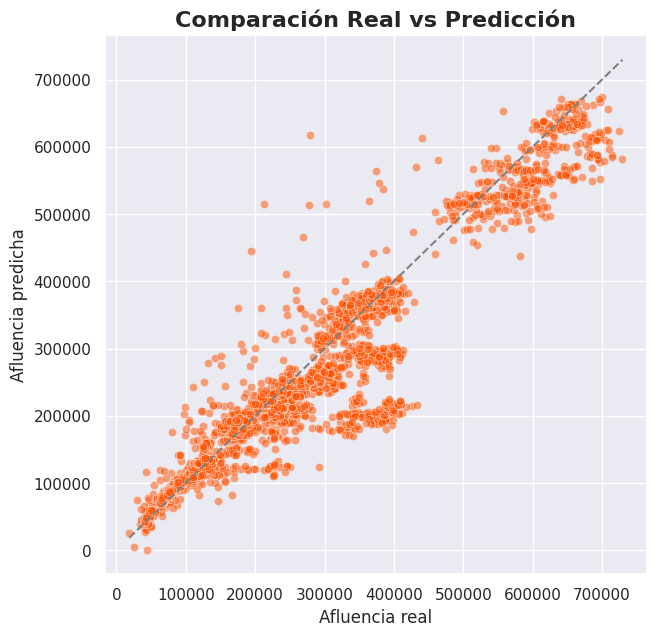

In [290]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color="#fe5000")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='gray')
plt.xlabel("Afluencia real")
plt.ylabel("Afluencia predicha")
plt.title("Comparación Real vs Predicción",fontsize=16,fontweight='bold')
plt.show()

### Gráfico de errores

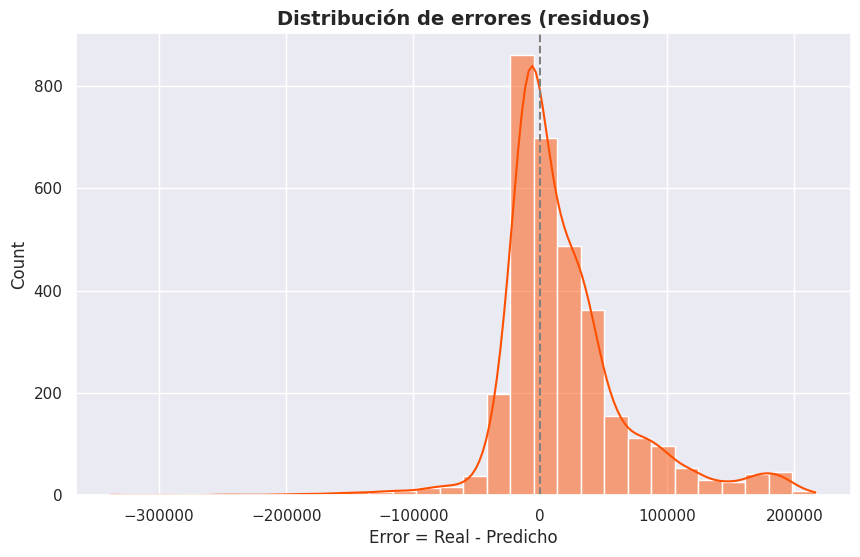

In [291]:
residuos = y_test - y_pred
plt.figure(figsize=(10,6))
sns.histplot(
    residuos,
    bins=30,
    kde=True,
    color='#FE5000'
)
plt.axvline(0,color='gray',linestyle='--')
plt.xlabel('Error = Real - Predicho')
plt.title('Distribución de errores (residuos)',fontsize=14,fontweight='bold')
plt.show()

In [292]:
test.columns

Index(['fecha', 'afluencia', 'anio', 'mes', 'dia', 'dia_semana', 'dia_anio',
       'es_fin_de_semana', 'linea_Línea 1', 'linea_Línea 12', 'linea_Línea 2',
       'linea_Línea 3', 'linea_Línea 4', 'linea_Línea 5', 'linea_Línea 6',
       'linea_Línea 7', 'linea_Línea 8', 'linea_Línea 9', 'linea_Línea A',
       'linea_Línea B', 'prediccion'],
      dtype='object')

### Barplot de error medio absoluto (MAE) por línea

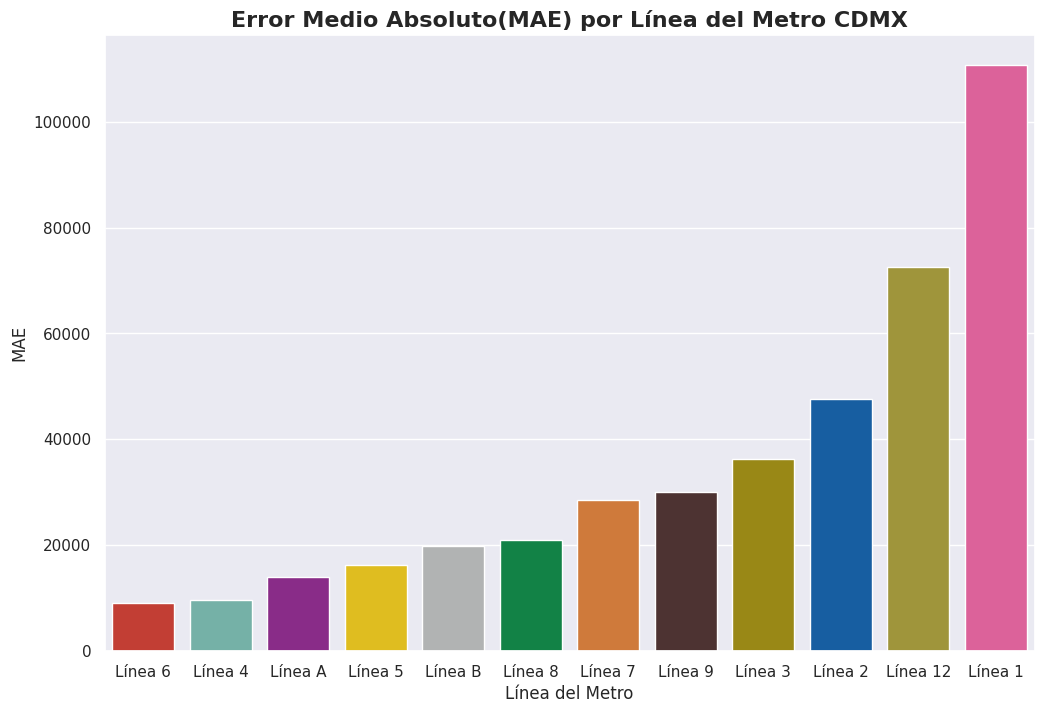

In [293]:
test_df = X_test.copy()
test_df['real'] = y_test
test_df['pred'] = y_pred
cols_lineas = [c for c in test_df.columns if c.startswith('linea_')]
test_df['linea'] = test_df[cols_lineas].idxmax(axis=1).str.replace('linea_','')

test_df['error_abs'] = abs(test_df['real']-test_df['pred'])

mae_por_linea = test_df.groupby('linea')['error_abs'].mean().sort_values()
plt.figure(figsize=(12,8))
sns.barplot(
    x=mae_por_linea.index,
    y=mae_por_linea.values,
    palette=colores_metro,
    hue=mae_por_linea.index
)
plt.title('Error Medio Absoluto(MAE) por Línea del Metro CDMX',fontsize=16,
          fontweight='bold')
plt.ylabel('MAE')
plt.xlabel('Línea del Metro')
plt.show()

In [294]:
mae_por_linea.sort_values(ascending=False)

,error_abs
linea,
Línea 1,110764.800223
Línea 12,72556.892084
Línea 2,47541.584821
Línea 3,36267.546074
Línea 9,30017.209564
Línea 7,28506.292525
Línea 8,20993.428342
Línea B,19783.105197
Línea 5,16354.710623


### Real vs Predicho por Línea

/tmp/ipython-input-961176738.py:12: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  sns.barplot(


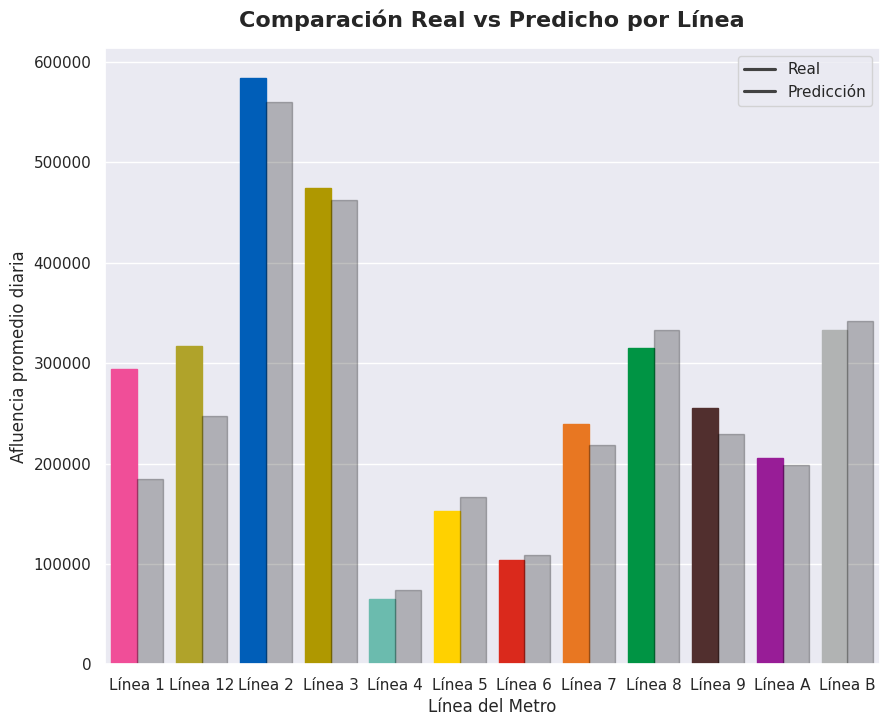

In [295]:
comparacion_linea = (
    test_df.groupby('linea')[['real','pred']].mean().reset_index()
)
comparacion_linea_melt = comparacion_linea.melt(
    id_vars='linea',
    value_vars=['real','pred'],
    var_name='Tipo',
    value_name='Afluencia'
)

plt.figure(figsize=(10,8))
sns.barplot(
    data=comparacion_linea_melt,
    x='linea',
    y='Afluencia',
    hue='Tipo',
    palette={
        'real':[colores_metro.get(l,'#999999') for l in comparacion_linea['linea']],
        'pred':['#00000040']*len(comparacion_linea['linea'])
    }['real']
)

bars = plt.gca().patches
num_lineas = len(comparacion_linea['linea'])
for i, bar in enumerate(bars):
    if i < num_lineas:
        bar.set_color(colores_metro.get(comparacion_linea['linea'][i],'#999999'))
    else:
        bar.set_color('#00000040')

plt.xlabel('Línea del Metro')
plt.ylabel('Afluencia promedio diaria')
plt.title('Comparación Real vs Predicho por Línea',fontsize=16,fontweight='bold',
          pad=15)
plt.legend(title='',labels=['Real','Predicción'],loc='upper right')
plt.show()

### Gráfico de Dispersión (Real vs Predicho)

#### Scatter General

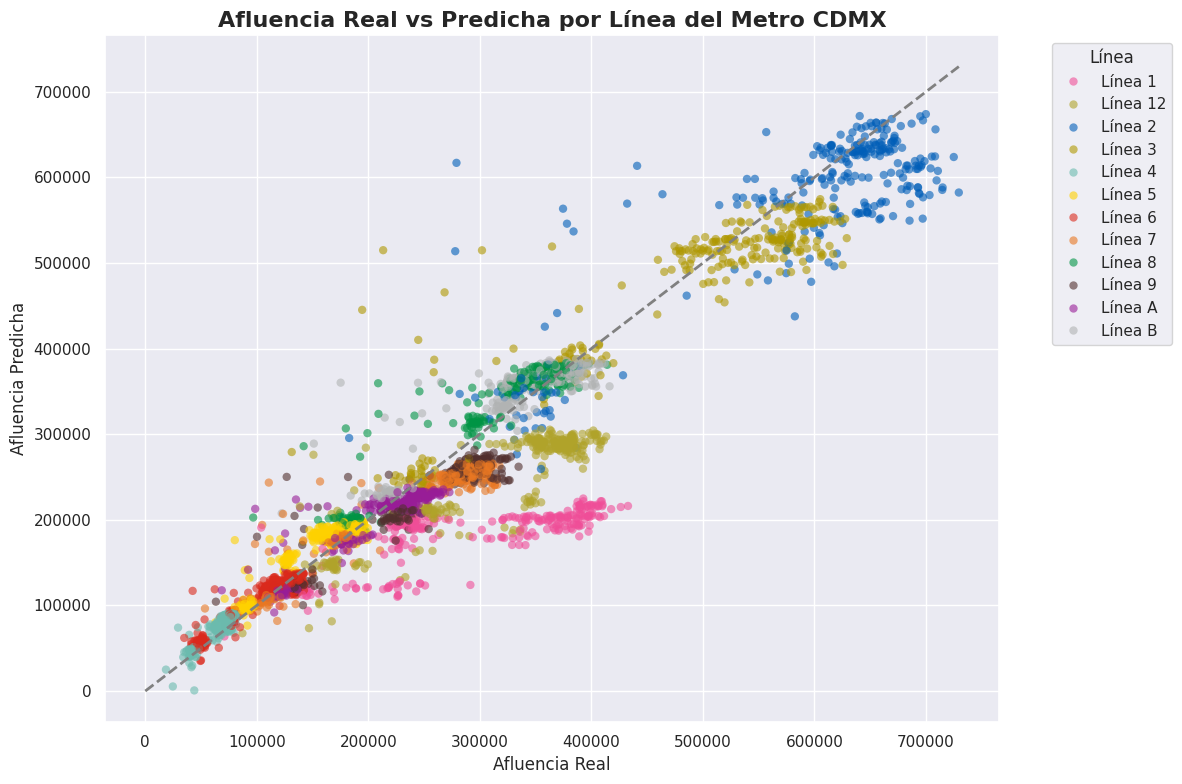

In [296]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=test_df,
    x='real',
    y='pred',
    hue='linea',
    palette=colores_metro,
    alpha=0.6,
    edgecolor='none'
)

# Diagonal ideal (perfect prediction)
max_val = max(test_df['real'].max(), test_df['pred'].max())
plt.plot([0, max_val], [0, max_val], '--', color='gray', lw=2)

plt.title('Afluencia Real vs Predicha por Línea del Metro CDMX', fontsize=16, fontweight='bold')
plt.xlabel('Afluencia Real')
plt.ylabel('Afluencia Predicha')
plt.legend(title='Línea', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Subplots

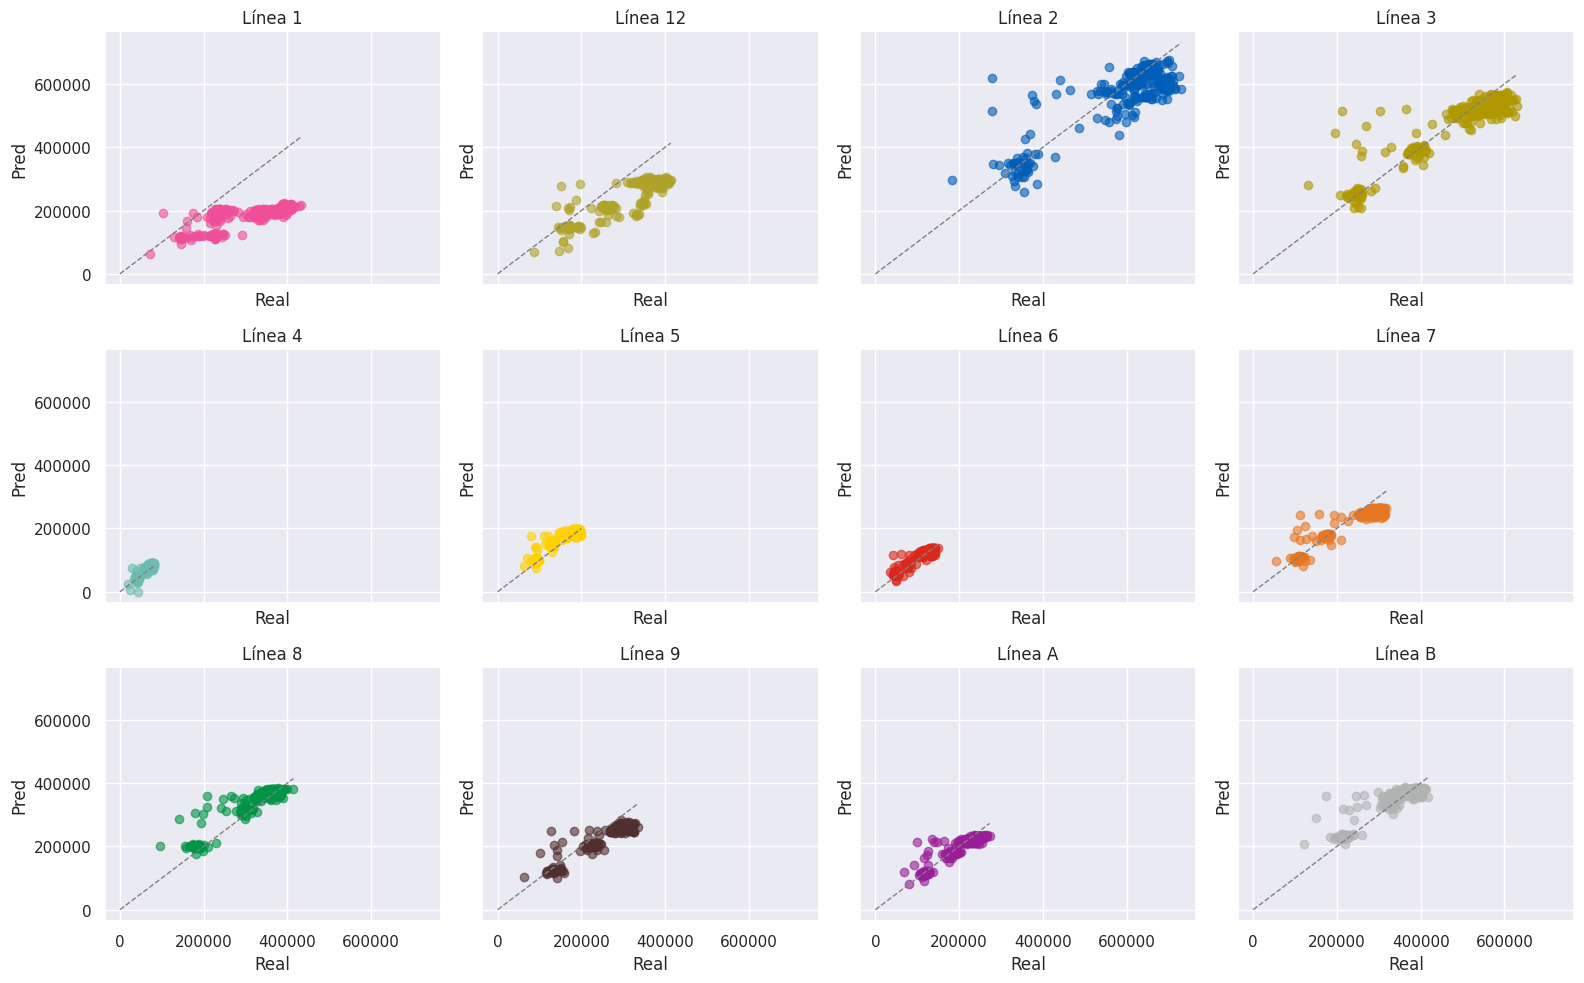

In [297]:
lineas = test_df['linea'].unique()
n = len(lineas)
cols = 4
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, linea in enumerate(lineas):
    subset = test_df[test_df['linea'] == linea]
    axes[i].scatter(subset['real'], subset['pred'], color=colores_metro.get(linea, '#999999'), alpha=0.6)
    axes[i].plot([0, subset['real'].max()], [0, subset['real'].max()], '--', color='gray', lw=1)
    axes[i].set_title(linea)
    axes[i].set_xlabel('Real')
    axes[i].set_ylabel('Pred')

plt.tight_layout()
plt.show()


## 5. Modelo con Modificaciones

### Normalizando variable objetivo

In [298]:
# Normalizar variable objetivo
df_lineas['afluencia_log'] = np.log1p(df_lineas['afluencia'])

### Agregando días festivos

In [299]:
import holidays
mx_holidays = holidays.Mexico(years=range(2010,2026))
# Fechas a datetime
fechas_feriado = pd.to_datetime(list(mx_holidays.keys()))
df_lineas['es_feriado'] = df_lineas['fecha'].isin(fechas_feriado).astype(int)


### Variables cíclicas

Como mes y día de la semana son variables circulares, habrá que modelar esa característica.

In [300]:
df_lineas['mes_sin'] = np.sin(2*np.pi*df_lineas['mes']/12)
df_lineas['mes_cos'] = np.cos(2*np.pi*df_lineas['mes']/12)

df_lineas['dia_semana_sin'] = np.sin(2*np.pi*df_lineas['dia_semana']/7)
df_lineas['dia_semana_cos'] = np.cos(2*np.pi*df_lineas['dia_semana']/7)

### Lag Features

In [301]:
df_lineas = df_lineas.sort_values(['linea','fecha'])
df_lineas['lag1'] = df_lineas.groupby('linea')['afluencia_log'].shift(1)
df_lineas['lag7']= df_lineas.groupby('linea')['afluencia_log'].shift(7)
df_lineas['lag14']= df_lineas.groupby('linea')['afluencia_log'].shift(14)
df_lineas['lag28']= df_lineas.groupby('linea')['afluencia_log'].shift(28)

### Rolling Windows

In [302]:
df_lineas['rolling7'] = df_lineas['afluencia_log'].rolling(7).mean()
df_lineas['rolling14'] = df_lineas['afluencia_log'].rolling(14).mean()
df_lineas['rolling30'] = df_lineas['afluencia_log'].rolling(30).mean()

### Sets de Entrenamiento y Prueba

In [312]:
train_2 = df_lineas[df_lineas['anio'].between(2010,2024)]
test_2 = df_lineas[df_lineas['anio'] == 2025]

### Dummies de Lineas

In [320]:
train_2 = pd.get_dummies(train_2, columns=['linea'], drop_first=False, dtype=int)
test_2 = pd.get_dummies(test_2, columns=['linea'], drop_first=False, dtype=int)

train_2, test_2 = train_2.align(test_2, join='left', axis=1, fill_value=0)

### Variables predictoras y objetivo

In [322]:
features = ['anio','mes','dia','dia_semana','dia_anio','es_fin_de_semana','es_feriado',
            'mes_sin','mes_cos','dia_semana_sin','dia_semana_cos','lag1',
            'lag7','lag14','lag28','rolling7','rolling14','rolling30']
features += [c for c in train_2.columns if c.startswith('linea_')]

X_train_2 = train_2[features]
y_train_2 = train_2['afluencia_log']

# Prueba
X_test_2 = test_2[features]
y_test_2 = test_2['afluencia']

print('X_train tamaño', X_train_2.shape)
print('y_train tamaño', y_train_2.shape)
print('X_test tamaño', X_test_2.shape)
print('y_test tamaño', y_test_2.shape)

X_train tamaño (65748, 30)
y_train tamaño (65748,)
X_test tamaño (3276, 30)
y_test tamaño (3276,)


### Modelo 2

In [321]:
model2 = XGBRegressor(
    n_estimators = 500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
# Entrenar
model2.fit(X_train_2,y_train_2)

# Predicción para 2025
pred_log = model2.predict(X_test_2)
# Escala real
pred = np.expm1(pred_log)

# Add predictions to test_2 for plotting
test_2['prediccion'] = pred

# Evaluacion
mae = mean_absolute_error(y_test_2,pred)
rmse = mean_squared_error(y_test_2,pred)
r2 = r2_score(y_test_2,pred)

print(f"Prueba (2025)  MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

Prueba (2025)  MAE: 12164.80 | RMSE: 413490240.00 | R²: 0.984


### Visualizaciones

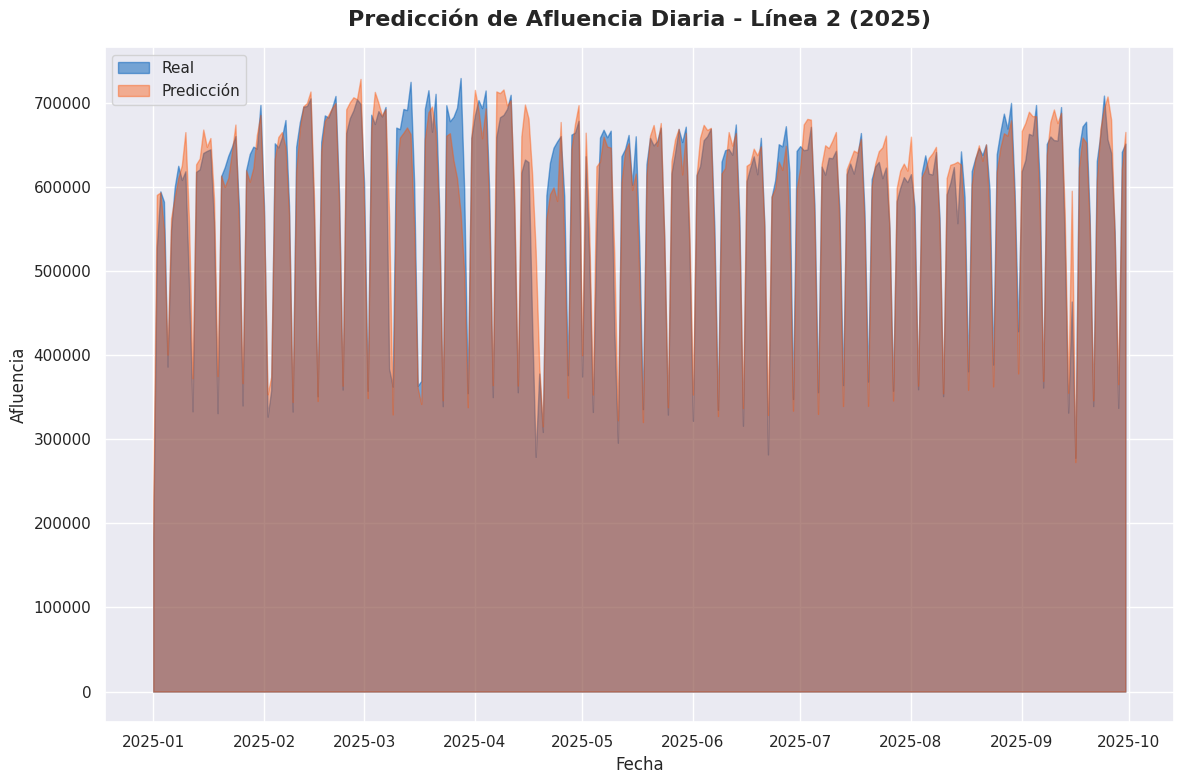

In [323]:
linea2 = test_2[test_2['linea_Línea 2'] == 1]

plt.figure(figsize=(12,8))

plt.fill_between(linea2['fecha'], linea2['afluencia'],
                 color='#005EB8', alpha=0.5, label='Real')

plt.fill_between(linea2['fecha'], linea2['prediccion'],
                 color='#FE5000', alpha=0.4, label='Predicción')

plt.xlabel('Fecha')
plt.ylabel('Afluencia')
plt.title('Predicción de Afluencia Diaria - Línea 2 (2025)',
          fontsize=16, fontweight='bold', pad=15)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

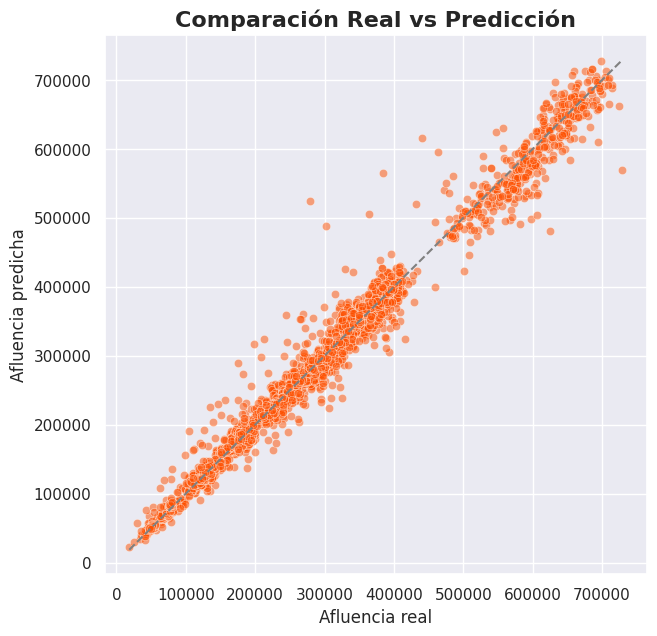

In [324]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test_2, y=pred, alpha=0.5, color="#fe5000")
plt.plot([y_test_2.min(), y_test_2.max()],
         [y_test_2.min(), y_test_2.max()],
         '--', color='gray')
plt.xlabel("Afluencia real")
plt.ylabel("Afluencia predicha")
plt.title("Comparación Real vs Predicción",fontsize=16,fontweight='bold')
plt.show()

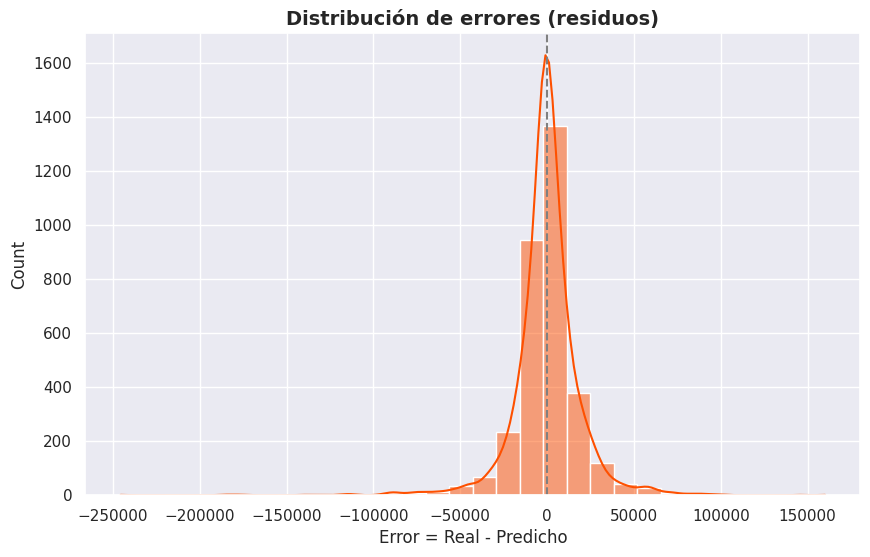

In [325]:
residuos = y_test_2 - pred
plt.figure(figsize=(10,6))
sns.histplot(
    residuos,
    bins=30,
    kde=True,
    color='#FE5000'
)
plt.axvline(0,color='gray',linestyle='--')
plt.xlabel('Error = Real - Predicho')
plt.title('Distribución de errores (residuos)',fontsize=14,fontweight='bold')
plt.show()

In [329]:
X_test_2.columns

Index(['anio', 'mes', 'dia', 'dia_semana', 'dia_anio', 'es_fin_de_semana',
       'es_feriado', 'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
       'lag1', 'lag7', 'lag14', 'lag28', 'rolling7', 'rolling14', 'rolling30',
       'linea_Línea 1', 'linea_Línea 12', 'linea_Línea 2', 'linea_Línea 3',
       'linea_Línea 4', 'linea_Línea 5', 'linea_Línea 6', 'linea_Línea 7',
       'linea_Línea 8', 'linea_Línea 9', 'linea_Línea A', 'linea_Línea B'],
      dtype='object')

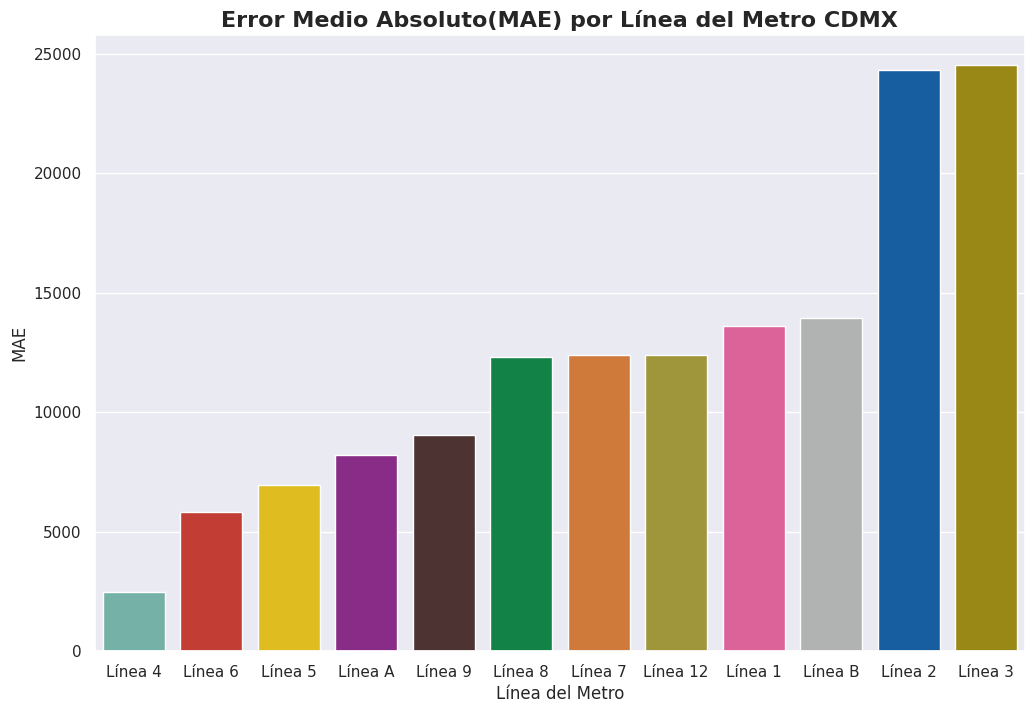

In [336]:
test_df_2 = X_test_2.copy()
test_df_2['real'] = y_test_2
test_df_2['pred'] = pred
cols_lineas = [c for c in test_df_2.columns if c.startswith('linea_')]
test_df_2['linea'] = test_df_2[cols_lineas].idxmax(axis=1).str.replace('linea_','')

test_df_2['error_abs'] = abs(test_df_2['real']-test_df_2['pred'])

mae_por_linea = test_df_2.groupby('linea')['error_abs'].mean().sort_values()
plt.figure(figsize=(12,8))
sns.barplot(
    x=mae_por_linea.index,
    y=mae_por_linea.values,
    palette=colores_metro,
    hue=mae_por_linea.index
)
plt.title('Error Medio Absoluto(MAE) por Línea del Metro CDMX',fontsize=16,
          fontweight='bold')
plt.ylabel('MAE')
plt.xlabel('Línea del Metro')
plt.show()

In [331]:
mae_por_linea.sort_values(ascending=False)

,error_abs
linea,
Línea 3,24537.784169
Línea 2,24321.615270
Línea B,13938.577152
Línea 1,13605.008270
Línea 12,12405.613753
Línea 7,12397.429373
Línea 8,12292.289606
Línea 9,9028.983717
Línea A,8221.098443


In [333]:
test_df.columns

Index(['anio', 'mes', 'dia', 'dia_semana', 'dia_anio', 'es_fin_de_semana',
       'es_feriado', 'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
       'lag1', 'lag7', 'lag14', 'lag28', 'rolling7', 'rolling14', 'rolling30',
       'linea_Línea 1', 'linea_Línea 12', 'linea_Línea 2', 'linea_Línea 3',
       'linea_Línea 4', 'linea_Línea 5', 'linea_Línea 6', 'linea_Línea 7',
       'linea_Línea 8', 'linea_Línea 9', 'linea_Línea A', 'linea_Línea B',
       'real', 'pred', 'linea', 'error_abs'],
      dtype='object')

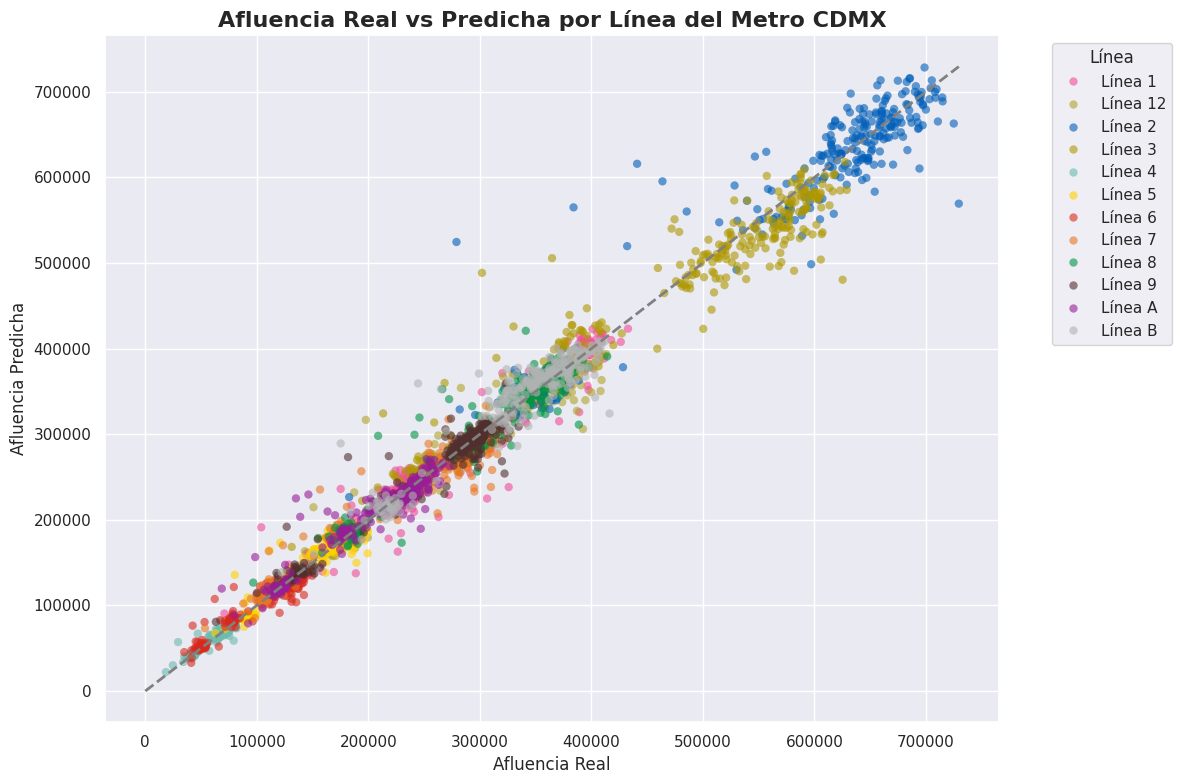

In [337]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=test_df_2,
    x='real',
    y='pred',
    hue='linea',
    palette=colores_metro,
    alpha=0.6,
    edgecolor='none'
)

# Diagonal ideal (perfect prediction)
max_val = max(test_df['real'].max(), test_df['pred'].max())
plt.plot([0, max_val], [0, max_val], '--', color='gray', lw=2)

plt.title('Afluencia Real vs Predicha por Línea del Metro CDMX', fontsize=16, fontweight='bold')
plt.xlabel('Afluencia Real')
plt.ylabel('Afluencia Predicha')
plt.legend(title='Línea', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

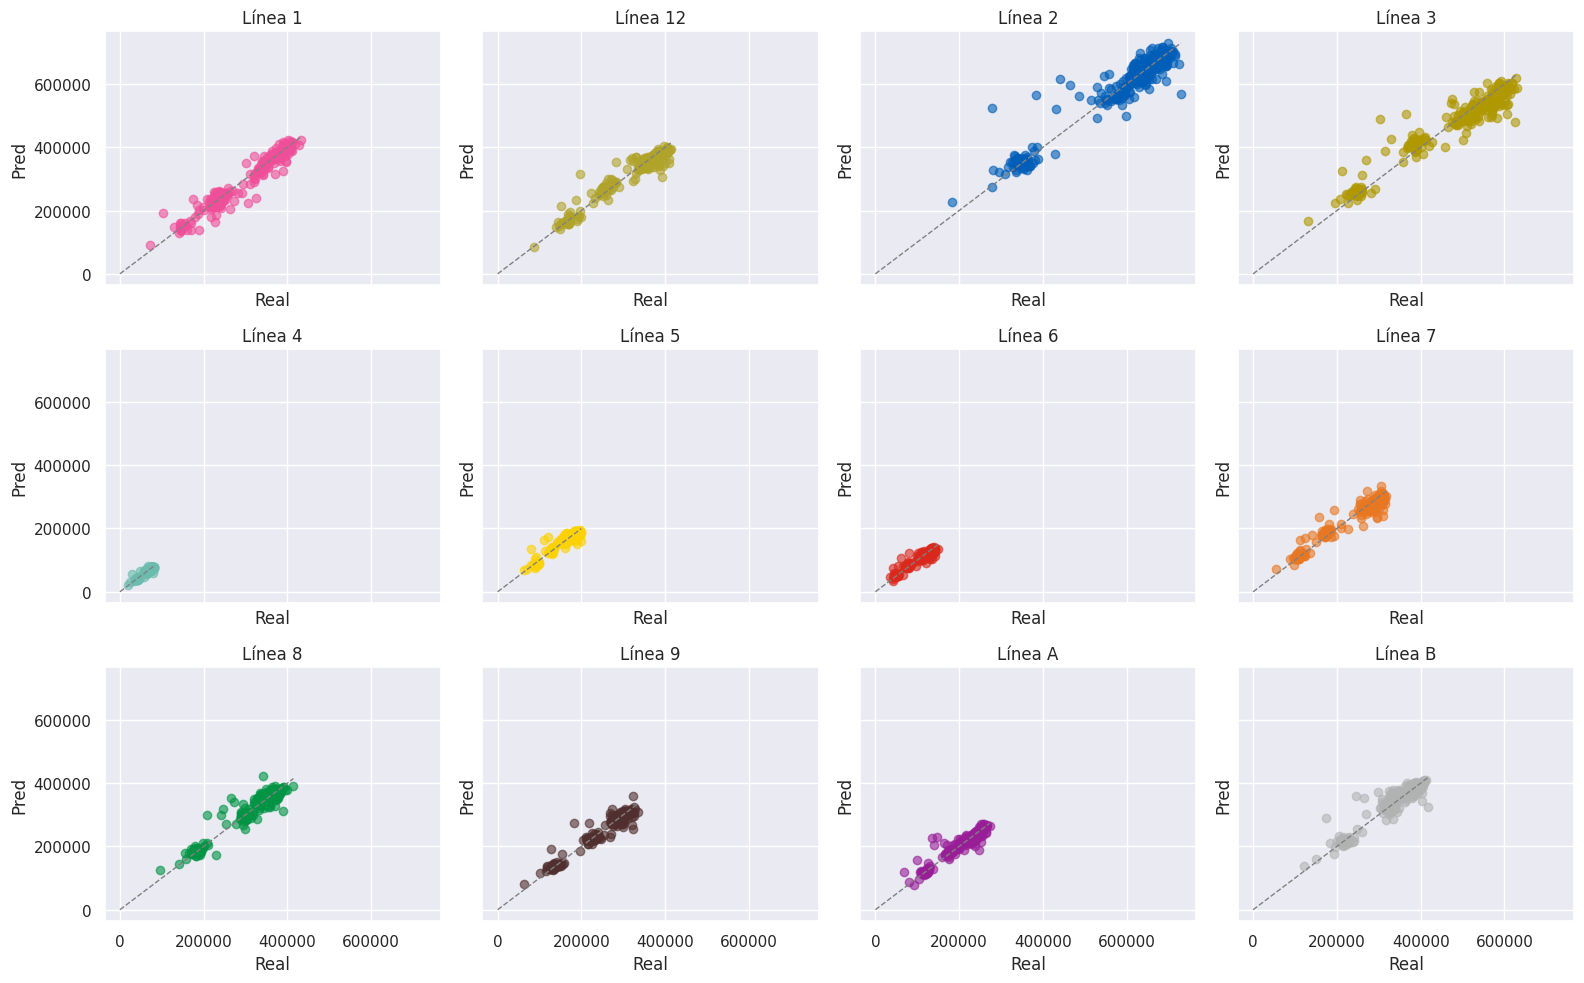

In [339]:
lineas = test_df_2['linea'].unique()
n = len(lineas)
cols = 4
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, linea in enumerate(lineas):
    subset = test_df_2[test_df['linea'] == linea]
    axes[i].scatter(subset['real'], subset['pred'], color=colores_metro.get(linea, '#999999'), alpha=0.6)
    axes[i].plot([0, subset['real'].max()], [0, subset['real'].max()], '--', color='gray', lw=1)
    axes[i].set_title(linea)
    axes[i].set_xlabel('Real')
    axes[i].set_ylabel('Pred')

plt.tight_layout()
plt.show()